In [13]:
import datasets
import keras_hub
import transformers
import numpy as np
import tensorflow as tf
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import keras
from collections.abc import Callable

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

In [3]:
train = datasets.load_dataset('wangrongsheng/ag_news', split='train')
test  = datasets.load_dataset('wangrongsheng/ag_news', split='test')

In [9]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2')

In [10]:
tokenizer.pad_token = tokenizer.eos_token

In [12]:
def get_name(pref: str | None, suf: str, sep: str = '_') -> str | None:
    return pref and pref + sep + suf

In [24]:
def get_lstm_layer(ndim: int, name: None | str = None) -> Callable[[keras.KerasTensor, tuple[keras.KerasTensor, keras.KerasTensor]], tuple[keras.KerasTensor, tuple[keras.KerasTensor, keras.KerasTensor]]]:
    forget_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'forget_gate'))
    input_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'input_gate'))
    tanh = keras.layers.Dense(ndim, activation='tanh', name=get_name(name, 'tanh'))
    output_gate = keras.layers.Dense(ndim, activation='sigmoid', name=get_name(name, 'output_gate'))
    mul_1 = keras.layers.Multiply(name=get_name(name, 'mul_1'))
    mul_2 = keras.layers.Multiply(name=get_name(name, 'mul_2'))
    mul_3 = keras.layers.Multiply(name=get_name(name, 'mul_3'))

    add = keras.layers.Add(name=get_name(name, 'add'))
    concat = keras.layers.Concatenate(name=get_name(name, 'concat'))
    def lstm(x: keras.KerasTensor, state: tuple[keras.KerasTensor, keras.KerasTensor]) -> tuple[keras.KerasTensor, tuple[keras.KerasTensor, keras.KerasTensor]]:
        l, s = state
        xs = concat([x, s])
        l = mul_1([l, forget_gate(xs)])
        l = add([l, mul_2([input_gate(xs), tanh(xs)])])
        s = mul_3([output_gate(xs), keras.activations.tanh(l)])
        return s, (l, s)
    return lstm

In [36]:
lstm = get_lstm_layer(128, 'first')
lstm

<function __main__.get_lstm_layer.<locals>.lstm(x: keras.src.backend.common.keras_tensor.KerasTensor, state: tuple[keras.src.backend.common.keras_tensor.KerasTensor, keras.src.backend.common.keras_tensor.KerasTensor]) -> tuple[keras.src.backend.common.keras_tensor.KerasTensor, tuple[keras.src.backend.common.keras_tensor.KerasTensor, keras.src.backend.common.keras_tensor.KerasTensor]]>

In [37]:
x_input = keras.layers.Input((128,), name='x')
l_input = keras.layers.Input((128,), name='l')
s_input = keras.layers.Input((128,), name='s')

In [38]:
x = lstm(x_input, (l_input, s_input))

In [48]:
model = keras.Model(inputs=[x_input, [l_input, s_input]], outputs=x)

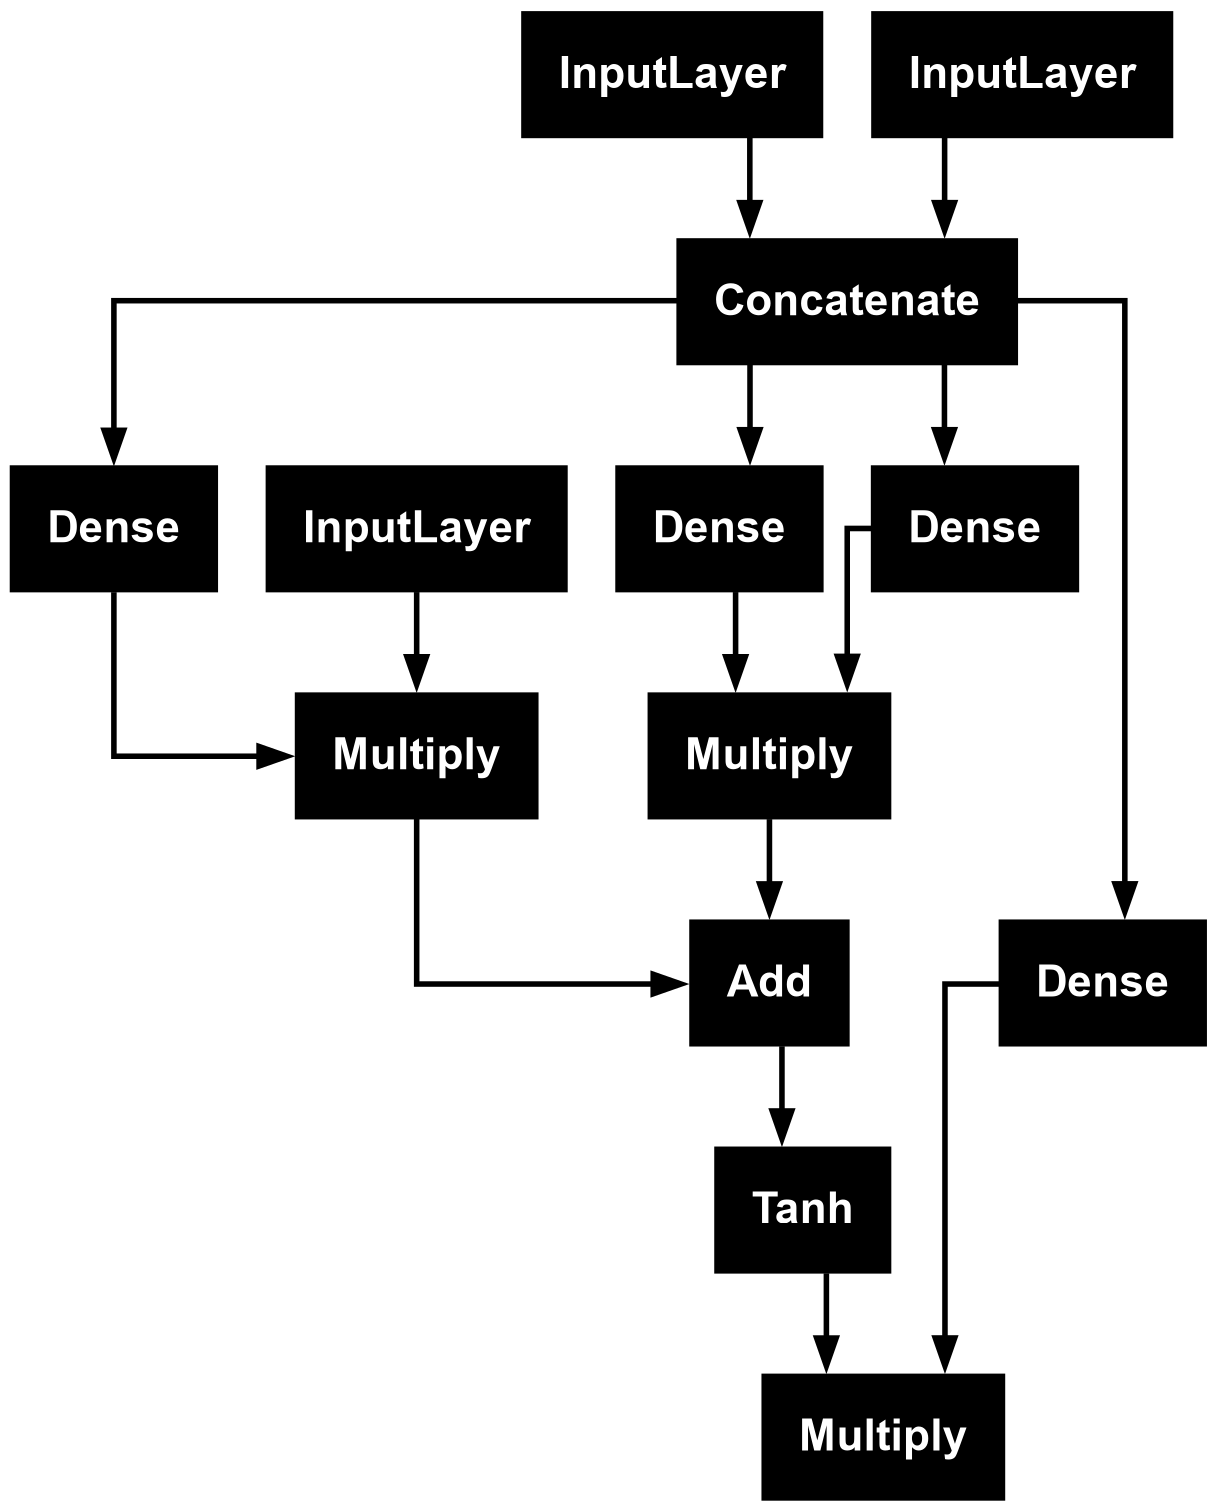

In [40]:
keras.utils.plot_model(model)

In [63]:
def get_gen_state_lstm(ndim: int):
    def gen_state_lstm(batch_size: int, dtype: tf.DType):
        return tf.zeros([batch_size, ndim], dtype=dtype), tf.zeros([batch_size, ndim], dtype=dtype)
    return gen_state_lstm

In [64]:
def apply_rnn(x: tf.Tensor, model: keras.Model, gen_state):
    batch_size = tf.shape(x)[0]
    state = gen_state(batch_size, x.dtype)
    n = tf.shape(x)[1]
    return tf.while_loop(
        (lambda i, _: tf.less(i, n)), 
        (lambda i, state: (i + 1, model([x[:, i], state])[1])),
        [tf.constant(0), state]
    )

In [67]:
@tf.function
def apply_rnn(x: tf.Tensor, model: keras.Model, gen_state):
    batch_size = tf.shape(x)[0]
    state = gen_state(batch_size, x.dtype)
    n = tf.shape(x)[1]
    i = tf.constant(0)
    while i < n:
        _, state = model([x[:, i], state])
        i = i + 1
    return i, state

In [68]:
apply_rnn(tf.random.uniform(shape=(2, 16, 128)), model, get_gen_state_lstm(128))

(<tf.Tensor: shape=(), dtype=int32, numpy=16>,
 (<tf.Tensor: shape=(2, 128), dtype=float32, numpy=
  array([[ 2.01316690e-03,  5.27536392e-01, -6.95858121e-01,
          -6.22484088e-01,  2.17631347e-02, -7.72264302e-01,
          -1.02851737e+00, -2.23896474e-01, -1.02763236e-01,
           2.18643332e+00, -2.58081779e-03, -3.77759159e-01,
          -4.28515881e-01,  1.31361857e-01,  1.01159573e-01,
           3.17836493e-01,  5.12708783e-01, -5.08465320e-02,
          -6.06084824e-01,  1.88287079e-01,  4.58900779e-01,
          -3.38143945e-01, -4.11739826e-01,  6.97026491e-01,
           3.19322273e-02,  5.26502207e-02, -1.33594418e+00,
          -5.51578760e-01,  3.62435654e-02, -1.63605154e-01,
          -2.19965577e-02, -1.28457379e-02,  2.30901361e-01,
          -3.31851155e-01, -8.92572403e-01, -2.38899320e-01,
          -9.68057662e-03, -3.60527277e-01, -2.32767403e-01,
          -9.45665613e-02,  1.26830623e-01,  1.28782183e-01,
           2.13127941e-01,  1.78652406e-01,  4.

In [49]:
model.inputs

[<KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=x>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=l>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=s>]

In [59]:
model.outputs

[<KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_42>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_39>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_42>]

In [62]:
len(model([tf.random.uniform(shape=(2,128)), [tf.random.uniform(shape=(2,128)), tf.random.uniform(shape=(2,128))]]))

2

In [77]:
sizes = []
for text in train['text']:
    sizes.append(len(tokenizer(text)['input_ids']))

(array([6.3000e+01, 3.8800e+02, 1.8170e+03, 2.3480e+03, 4.4380e+03,
        5.0180e+03, 9.9040e+03, 9.5160e+03, 1.4330e+04, 1.1267e+04,
        1.1292e+04, 1.3323e+04, 8.3700e+03, 8.5290e+03, 4.7540e+03,
        4.0580e+03, 2.0470e+03, 1.8230e+03, 9.3500e+02, 7.0900e+02,
        7.0800e+02, 3.9400e+02, 4.1500e+02, 2.4400e+02, 3.2600e+02,
        2.3200e+02, 3.5400e+02, 2.9500e+02, 3.9400e+02, 2.9900e+02,
        2.4000e+02, 2.7200e+02, 1.2400e+02, 1.1100e+02, 4.7000e+01,
        3.7000e+01, 2.7000e+01, 1.7000e+01, 1.4000e+01, 9.0000e+00,
        2.0000e+01, 1.1000e+01, 2.4000e+01, 1.9000e+01, 2.7000e+01,
        5.8000e+01, 5.5000e+01, 6.1000e+01, 5.8000e+01, 3.2000e+01,
        1.4000e+01, 2.2000e+01, 8.0000e+00, 4.0000e+00, 2.0000e+00,
        5.0000e+00, 6.0000e+00, 0.0000e+00, 2.0000e+00, 0.0000e+00,
        3.0000e+00, 4.0000e+00, 6.0000e+00, 3.0000e+00, 7.0000e+00,
        4.0000e+00, 5.0000e+00, 0.0000e+00, 6.0000e+00, 3.0000e+00,
        3.0000e+00, 2.0000e+00, 1.0000e+00, 3.00

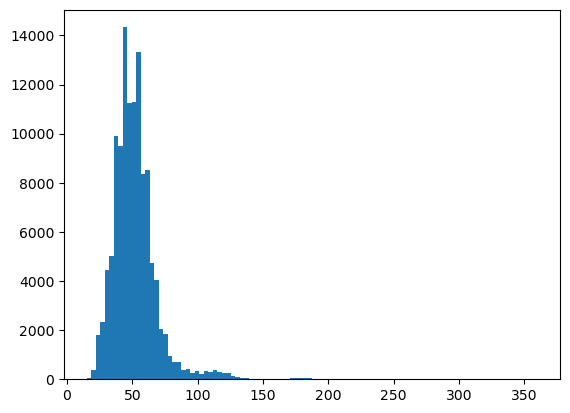

In [79]:
plt.hist(sizes, bins=100)